# Rotulagem por similaridade - não supervisionada

### Importar dados do Google Drive

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
docs =  pd.read_csv('/content/drive/MyDrive/datasets/dissertacao/processed/trump_marcelo_processed.csv')
query_set = pd.read_csv('/content/drive/MyDrive/datasets/dissertacao/validation.csv')



#against = query_set[query_set.target == "AGAINST"].sample(n=140, random_state=44)
#favor = query_set[query_set.target == "FAVOR"].sample(n=140, random_state=44)
#query_set = pd.concat([favor,against])

#query_set = query_set[query_set.target != "NONE"]
#query_set = query_set.reset_index().drop(columns='index')

### Importar dados do computador local

In [ ]:
import pandas as pd

docs = pd.read_csv('../data/processed/trump_marcelo_processed.csv')

### Extração de clusters

In [ ]:
import sys

if 'bertopic' not in sys.modules:
    print('Installing requeriment..')
    ! pip install bertopic
else:
    print('Requirement already satisfied..')

In [ ]:
import torch

if torch.cuda.is_available():        
    device = torch.device("cuda")    
    print('There are %d GPU(s) available.' % torch.cuda.device_count())    
    print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

In [1]:
import os

import hdbscan
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP

os.environ["TOKENIZERS_PARALLELISM"] = "false"

model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")
#model = SentenceTransformer("multi-qa-mpnet-base-dot-v1", device="cuda")


#trump_marcelo_concat
#umap_model = UMAP(n_neighbors=11, n_components=8, metric='cosine')

umap_model = UMAP(n_components=3 ,n_neighbors=9, random_state=42, metric='cosine')


hdbscan_model = hdbscan.HDBSCAN(#min_cluster_size = 15, trump_marcelo_concact
                                min_cluster_size=15,
                                metric='euclidean', 
                                cluster_selection_method='eom')


vectorizer_model = CountVectorizer(ngram_range=(2, 2), stop_words="english")



topic_model = BERTopic(embedding_model=model,
                       top_n_words=10,
                       #nr_topics = 'auto',
                       umap_model=umap_model,
                       hdbscan_model=hdbscan_model,
                       vectorizer_model=vectorizer_model,
                       low_memory=True,
                       calculate_probabilities=False, 
                       verbose=True)

/home/andre/Documentos/Workspace/mestrado/dissertacao/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2022-12-23 14:36:17.362127: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-12-23 14:36:17.443682: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2022-12-23 14:36:17.860327: W tensorflow/compiler/x

In [2]:
topics, probs = topic_model.fit_transform(docs.text)

Batches: 100%|██████████| 2961/2961 [00:14<00:00, 199.06it/s]
2022-12-23 14:36:38,208 - BERTopic - Transformed documents to Embeddings
2022-12-23 14:37:59,818 - BERTopic - Reduced dimensionality
2022-12-23 14:38:01,994 - BERTopic - Clustered reduced embeddings


In [ ]:
topic_model.visualize_topics()

In [3]:
topic_docs = {topic: [] for topic in set(topics)}
for topic, doc in zip(topics, docs.text):
    topic_docs[topic].append(doc)

### Buscar os clusters correspondentes a cada linha do query set e atribuir-los a label correspondente

- Desafios
    - O mesmo tópico pode ser atrbuído a rótulos diferentes dependendo da consulta
        - Criar sistema para atribuir ao tópico o rótulo mais frequênte


In [4]:
def find_clusters(query_set):
    clusters_list = list()
    for index in range(len(query_set)):
        finded_clusters = topic_model.find_topics(query_set.text[index])
        proba_index = 0
        for cluster_number in finded_clusters[0]:
            if cluster_number != -1:
                assigned_clusters = {
                    "number": cluster_number,
                    "label" : query_set.target[index],
                    "proba" : finded_clusters[1][proba_index]
                }
                clusters_list.append(assigned_clusters)
                proba_index += 1
           

    return pd.DataFrame(clusters_list)

In [5]:
import numpy as np

def assingn_most_representative_label_by_proba(pre_labeled_clusters, threshold):
    clusters_list = list()
    for cluster_number in pre_labeled_clusters.number.unique():
        grouped_topics = pre_labeled_clusters[pre_labeled_clusters.number == cluster_number].groupby(['number','proba','label']).proba.max()
        max_proba = grouped_topics.values.max()
        if max_proba >= threshold:
            most_frequent_label = {
                'number': cluster_number,
                'label' : grouped_topics.index[np.argmax(grouped_topics)][2]  
            }
            clusters_list.append(most_frequent_label)
    return pd.DataFrame(clusters_list)

In [6]:
import numpy as np

def assingn_most_representative_label_by_frequency(pre_labeled_clusters):
    clusters_list = list()
    for cluster_number in pre_labeled_clusters.number.unique():
        grouped_topics = pre_labeled_clusters[pre_labeled_clusters.number == cluster_number].groupby(['number','label']).label.count()
        most_frequent_label = {
            'number': cluster_number,
            'label' : grouped_topics.index[np.argmax(grouped_topics)][1]  
        }
        clusters_list.append(most_frequent_label)
    return pd.DataFrame(clusters_list)

### Rotular  os documentos presentes nos clusters com as labels correspondente

In [7]:
def dataset_documents_labeling(labeled_clusters):
    docs_list = list()
    for cluster_number in labeled_clusters.number:
       for docs in topic_docs[cluster_number]:
                    docs ={
                        "text": docs,
                        "label": labeled_clusters[labeled_clusters.number == cluster_number].label.values[0]
                    }
                    docs_list.append(docs)

    return pd.DataFrame(docs_list)

### Executando o pipeline

In [9]:
pre_labeled_clusters = find_clusters(query_set)

In [ ]:
labeled_clusters = assingn_most_representative_label_by_proba(pre_labeled_clusters, 0.6)
labeled_dataset =  dataset_documents_labeling(labeled_clusters)
labeled_dataset.to_csv('../data/labeled_dataset_mean_tweets.csv', index=False)
sns.countplot(x=labeled_dataset['label'], label = 'count')

<AxesSubplot: xlabel='label', ylabel='count'>

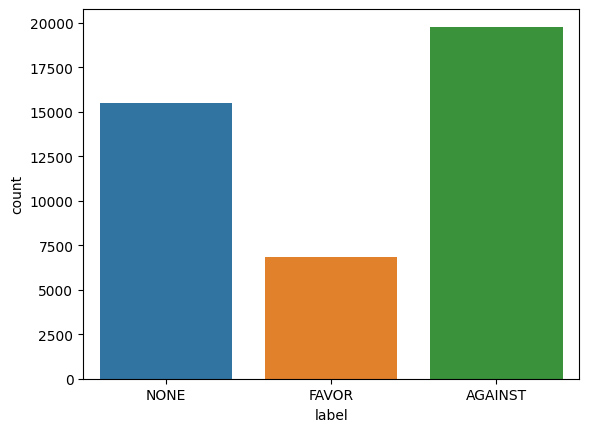

In [10]:
labeled_clusters = assingn_most_representative_label_by_frequency(pre_labeled_clusters)
labeled_dataset =  dataset_documents_labeling(labeled_clusters)
labeled_dataset.to_csv('../data/labeled_dataset_mean_tweets.csv', index=False)
sns.countplot(x=labeled_dataset['label'], label = 'count')